In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from pyomo.environ import *
from optimization_utils import *
from param_loader import METANET_Params
from simulation_utils import *
from mpc_utils import *

In [2]:
real_data = True

if real_data:
    q_hat = np.load("data/flow_10sec_400m_1hr.npy")
    # print(np.max(q_hat))
    rho_hat = np.load("data/density_10sec_400m_1hr.npy")
else:
    q_hat = np.load("data/q_synthetic.npy") #np.load("data/flow_10sec_400m_1hr.npy")
    # print(np.max(q_hat))
    rho_hat = np.load("data/p_synthetic.npy") #np.load("data/density_10sec_400m_1hr.npy")

v_hat = q_hat / rho_hat
print(rho_hat.shape)
flattened_q_hat = q_hat.flatten()
print(max(flattened_q_hat))
flattened_rho_hat = rho_hat.flatten()
C_i = np.mean(np.sort(flattened_q_hat)[-5:])
print("C_i", C_i)
K = len(flattened_rho_hat)
print("K", K)

rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)

(360, 16)
6773.200199999966
C_i 6718.716719999977
K 5760


In [3]:
lane_map = np.load("data/lane_mapping.npy")
lane_mapping = {i: float(lane_map[i+1]) for i in range(len(lane_map)-2)}
num_lanes_array = lane_map[1:-1]

ramp_mapping = {"on_ramps": np.load("data/on_ramp_mapping.npy")[1:-1], "off_ramps": np.load("data/off_ramp_mapping.npy")[1:-1]}
print(ramp_mapping)
print(lane_mapping)


{'on_ramps': array([False,  True, False, False, False, False, False, False, False,
       False,  True, False, False,  True]), 'off_ramps': array([False, False, False, False, False, False, False, False, False,
        True, False,  True, False, False])}
{0: 4.0, 1: 4.0, 2: 4.0, 3: 4.3539391649542445, 4: 5.0, 5: 5.0, 6: 5.0, 7: 5.0, 8: 4.860748562409972, 9: 4.0, 10: 4.0, 11: 4.050664946063771, 12: 4.507098142428658, 13: 4.0}


In [4]:
if not real_data:
    print(rho_hat.shape)
    print(q_hat.shape)
    downstream_density = np.full(rho_hat.shape[0], 0)
    data_inflow = np.array([5500 if i in range(20, 20 + 90) else 4000 for i in range(rho_hat.shape[0])])

    np.save("data/downstream_density_synthetic.npy", downstream_density)
    np.save("data/inflow_synthetic.npy", data_inflow)


    plt.figure(figsize=(12, 6))
    # plt.subplot(2, 1, 1)
    # plt.plot(rho_hat[:, 0], label="Density")
    plt.plot(downstream_density, label="Downstream Density")
    plt.legend()
    plt.subplot(2, 1, 2)
    # plt.plot(q_hat[:, 0], label="Flow")
    plt.plot(data_inflow, label="Upstream Inflow")
    plt.legend()
    plt.show()


In [5]:
num_calibrated_segments = rho_hat.shape[1] - 2  # Exclude boundary segments
T = 10/3600
l = 0.4

In [10]:
print("Simulating with calibrated parameters...")
# stop printing in scientific notation
np.set_printoptions(suppress=True)
# dynamic=True
# control_len = 90
# params = [METANET_Params(path="itsc_final/calibration_results/OCP", num_segments=num_calibrated_segments).get_params(),
#           METANET_Params(path="itsc_final/smooth_mpc_calibration_results", control_h=90, num_segments=num_calibrated_segments).get_params()]

# labels = ["Static\n", "Dynamic \n(Ours)"]

# data = {"Static\n": dict(), "Dynamic \n(Ours)": dict()}

params = [METANET_Params(path="ga_calibration_results", num_segments=num_calibrated_segments).get_params()]
labels = ["GA"]
percent_noise_list = []  # or whatever you want
data = {labels[0]: dict()}

# Scale densities per lane for simulation

scaled_rho_hat = rho_hat[:, 1:-1] / np.array(num_lanes_array)

# if smoothing boundary conditions
print(num_lanes_array)
downstream_density = smooth_inflow(rho_hat[:, -1]) / num_lanes_array[-1]
data_inflow = smooth_inflow(q_hat[:, 0])

# Sim requires tuple of initial conditions: density, velocity, inflow, and queue
init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)

for i in range(len(params)):
    param = params[i]
    rho_sim, v_sim, _, tts_sim = run_metanet_sim(
        T, 
        l, 
        init_traffic_state,
        data_inflow,
        downstream_density,
        param,
        vsl_speeds=None,
        lanes={i: num_lanes_array[i] for i in range(num_calibrated_segments)},
        plotting=True,
        real_data=True
    )
    data[labels[i]]["v_sim"] = v_sim

Simulating with calibrated parameters...
[4.         4.         4.         4.35393916 5.         5.
 5.         5.         4.86074856 4.         4.         4.05066495
 4.50709814 4.        ]


In [11]:
print(mape(v_hat[:, 1:-1], v_sim))

IndexError: boolean index did not match indexed array along axis 0; size of axis is 361 but size of corresponding boolean axis is 360

In [12]:
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

def _time_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return f"{dt.hour}:{dt.minute:02d}"

In [13]:
# List of noise levels you want to test
# percent_noise_list = [0.01, 1]  # or whatever you want

# Dicts to hold results for each noise level

for k in range(len(params)):
    param = params[k]
    label = labels[k]

    for percent_noise in percent_noise_list:
        plotting_v_sim = None
        plotting_rho_sim = None
        worst_v_sim = None

        perturbs = generate_perturbations(data_inflow, percent_noise, num=50)
        for perturbed_conditions in perturbs:
            rho_sim_noise, v_sim_noise, _, tts_noise = run_metanet_sim(T,
                                        l,
                                        init_traffic_state,
                                        perturbed_conditions,
                                        downstream_density,
                                        param, 
                                        vsl_speeds=None,
                                        lanes=num_lanes_array,
                                        plotting=True,
                                        real_data=True)
        
            error = mape(v_hat[:, 1:-1], v_sim_noise[0:-1, :])

            if worst_v_sim is None or error > worst_v_sim:
                plotting_v_sim = v_sim_noise
                plotting_rho_sim = rho_sim_noise
                worst_v_sim = error

        # Store outputs
        print(worst_v_sim)
        data[label][f"v_sim_noise_{percent_noise}"] = plotting_v_sim
    # noisy_tts_sim_dict[percent_noise] = tts_noise


In [24]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from datetime import datetime, timedelta

def plot_time_space_grid(
    data,
    labels,
    percent_noise_list,
    v_hat,
    value_key_base="v_sim",
    cmap="RdYlGn",
    figsize_per_col=3.0,
    figsize_per_row=3.0,
    g_fontsize=10,
    vmin=None,
    vmax=None,
    show_colorbar=True,
    clean_title="No noise",
    noise_title_fmt="{pct:g}% Added Noise",
    vhat_title=r"$v_{\hat{}}$",
    segment_length_km=0.4,
    dt_seconds=10,
    start_time_str="08:00",
    colorbar_label="Speed",
    save_path="noised_inflows.pdf",
    show_gt=False
    
):
    def _time_fmt(x, pos=None):
        dt = mdates.num2date(x)
        return f"{dt.hour}:{dt.minute:02d}"

    # Font scaling
    tick_fs = g_fontsize
    label_fs = g_fontsize + 1
    title_fs = g_fontsize + 1
    rowlabel_fs = g_fontsize + 2


    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": "Times New Roman", #["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],  # Use Computer Modern for text
        "mathtext.fontset": "cm",   # Computer Modern for math
        "pdf.fonttype": 42,  # Embed fonts in PDF output
        "ps.fonttype": 42,  # Embed fonts in PS output
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
        "text.usetex": False,
    })

    nrows = len(labels)
    ncols = 1 + len(percent_noise_list)

    # Collect arrays and shared color scale
    arrays_for_scale = []
    panel_arrays = {}

    for label in labels:
        clean_arr = np.asarray(data[label][value_key_base])
        panel_arrays[(label, "clean")] = clean_arr
        arrays_for_scale.append(clean_arr[:-1, :])

        for pct in percent_noise_list:
            key = f"{value_key_base}_noise_{pct}"
            arr = np.asarray(data[label][key])
            panel_arrays[(label, pct)] = arr
            arrays_for_scale.append(arr[:-1, :])

    # Use interior segments of v_hat to match simulated dimensions
    vhat_arr = np.asarray(v_hat[:, 1:-1])
    arrays_for_scale.append(vhat_arr)

    if vmin is None:
        vmin = min(np.nanmin(arr) for arr in arrays_for_scale)
    if vmax is None:
        vmax = max(np.nanmax(arr) for arr in arrays_for_scale)

    sample_arr = panel_arrays[(labels[0], "clean")]
    n_time, n_seg = sample_arr[:-1, :].shape

    start_dt = datetime.strptime(start_time_str, "%H:%M")
    end_dt = start_dt + timedelta(seconds=dt_seconds * n_time)

    y_min = 0.0
    y_max = n_seg * segment_length_km

    # Figure + gridspec

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_col * (ncols + 1.4), figsize_per_row * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    im = None

    for r, label in enumerate(labels):
        for c in range(ncols):
            ax = axes[r, c]

            if c == 0:
                arr = panel_arrays[(label, "clean")]
            else:
                pct = percent_noise_list[c - 1]
                arr = panel_arrays[(label, pct)]

            im = ax.imshow(
                arr[:-1, :].T,
                aspect="auto",
                origin="lower",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
                extent=[
                    mdates.date2num(start_dt),
                    mdates.date2num(end_dt),
                    y_min,
                    y_max,
                ],
            )

            if r == 0:
                if c == 0:
                    ax.set_title(clean_title, fontsize=title_fs)
                else:
                    pct = percent_noise_list[c - 1]
                    ax.set_title(noise_title_fmt.format(pct=pct), fontsize=title_fs)

            ax.tick_params(labelsize=tick_fs)

            if r == nrows - 1:
                ax.set_xlabel("Time", fontsize=label_fs)
                ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
                ax.xaxis.set_major_formatter(FuncFormatter(_time_fmt))
                for tick in ax.get_xticklabels():
                    tick.set_rotation(-20)
                    tick.set_ha("left")
            else:
                ax.tick_params(axis="x", labelbottom=False)

            if c == 0:
                ax.set_ylabel("Distance (km)", fontsize=label_fs)
            else:
                ax.tick_params(axis="y", labelleft=False)

    # Fewer y ticks
    yticks = np.arange(0, y_max + 1e-9, 1.4)
    for r in range(nrows):
        axes[r, 0].set_yticks(yticks)

    if show_gt:
        # Horizontal row labels
        for r, label in enumerate(labels):
            pos = axes[r, 0].get_position()
            y_center = pos.y1 + 0.03
            fig.text(
                pos.x0 - 0.2,
                y_center,
                label,
                ha="left",
                va="center",
                fontsize=rowlabel_fs - 1,
                # fontstyle="italic",
                fontweight="bold",
            )
        # ---------------------------------------------
        # Add centered v_hat and right-side colorbar
        # ---------------------------------------------
        fig.canvas.draw()

        top_pos = axes[0, -1].get_position()
        bot_pos = axes[-1, -1].get_position()

        # Use the same width as a regular subplot
        ref_pos = axes[0, 0].get_position()
        subplot_w = ref_pos.x1 - ref_pos.x0
        subplot_h = ref_pos.y1 - ref_pos.y0

        grid_y0 = bot_pos.y0
        grid_y1 = top_pos.y1
        grid_h = grid_y1 - grid_y0

        vhat_h = subplot_h
        vhat_w = subplot_w
        gap = 0.1
        cbar_w = 0.012

        vhat_x0 = top_pos.x1 + 0.035
        vhat_y0 = grid_y0 + 0.70 * (grid_h - vhat_h)

        ax_vhat = fig.add_axes(
            [vhat_x0, vhat_y0, vhat_w, vhat_h],
            sharex=axes[0, 0],
            sharey=axes[0, 0],
        )

        # Horizontal colorbar below v_hat
        cbar_h = 0.035
        cbar_gap = 0.18
        cax = fig.add_axes(
            [vhat_x0, vhat_y0 - cbar_gap - cbar_h, vhat_w, cbar_h]
        )

        vhat_arr = np.asarray(v_hat[:, 1:-1])

        im_vhat = ax_vhat.imshow(
            vhat_arr.T,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            extent=[
                mdates.date2num(start_dt),
                mdates.date2num(start_dt + timedelta(seconds=dt_seconds * vhat_arr.shape[0])),
                y_min,
                y_max,
            ],
        )

        ax_vhat.set_title(vhat_title, fontsize=title_fs)
        ax_vhat.tick_params(labelsize=tick_fs)
        ax_vhat.tick_params(axis="y", labelleft=False)
        ax_vhat.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
        ax_vhat.xaxis.set_major_formatter(FuncFormatter(_time_fmt))
        ax_vhat.set_xlabel("Time", fontsize=label_fs)
        ax_vhat.set_yticks(yticks)

        if show_colorbar:
            cbar = fig.colorbar(im_vhat, cax=cax, orientation="horizontal")
            cbar.set_label(colorbar_label, fontsize=label_fs)
            cbar.ax.tick_params(labelsize=tick_fs)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

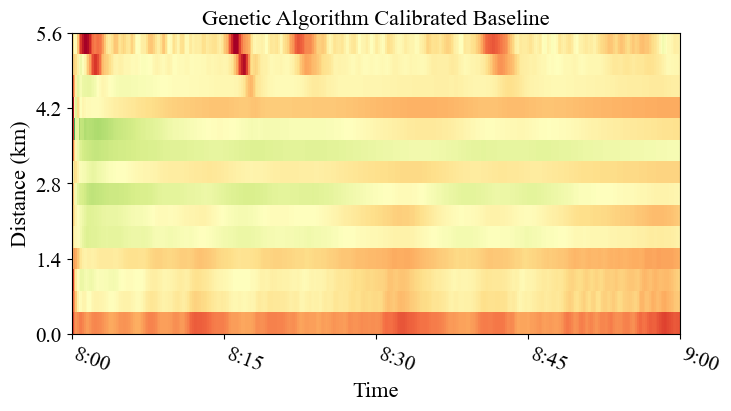

In [30]:
plot_time_space_grid(
    data=data,
    labels=labels,
    percent_noise_list=percent_noise_list,
    v_hat=v_hat,
    figsize_per_row=4.0,
    figsize_per_col=3.0,
    value_key_base="v_sim",
    vmin=0,
    vmax=110,
    cmap="RdYlGn",
    g_fontsize=15,
    colorbar_label="Velocity (km/h)",
    clean_title="Genetic Algorithm Calibrated Baseline",
    vhat_title="Ground Truth Velocity",
    save_path="itsc_final/figs/ga_ts_diagram.pdf",
)

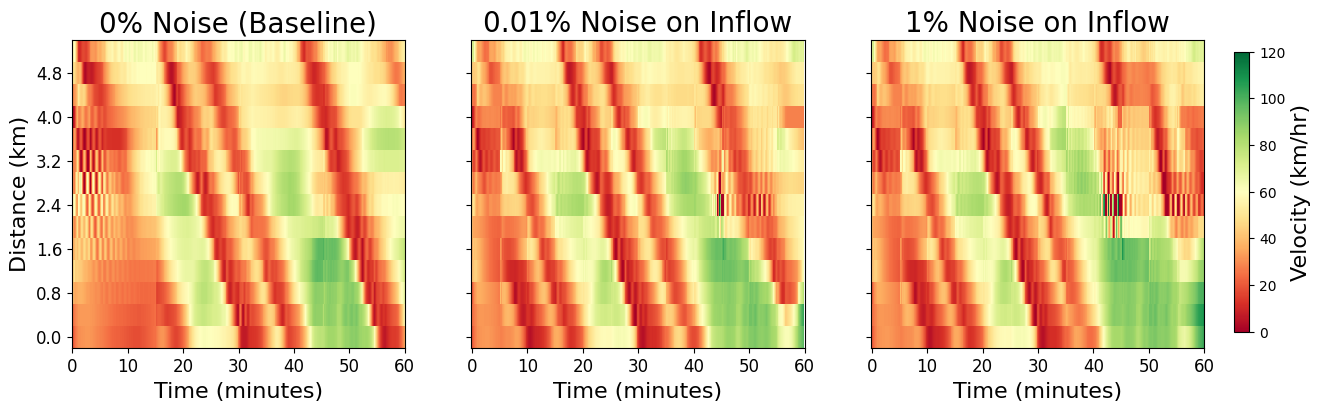

In [102]:
# Assume you already have:
# v_sim
# percent_noise_list = [5, 10, 20]  # for example
# noisy_v_sim_dict = {percent_noise: noisy_v_sim, ...}

n_cases = 1 + len(percent_noise_list)  # 1 for v_sim + one per noise level
fig, axes = plt.subplots(1, n_cases, figsize=(5 * n_cases, 4), sharey=True)

# Make sure axes is always iterable
if n_cases == 1:
    axes = np.array([axes])

# --- Compute common color scale across v_sim and all noisy v_sims ---
all_vs = [v_sim] + [noisy_v_sim_dict[p] for p in percent_noise_list]
vmin = 0 #min(np.min(v) for v in all_vs)
vmax = 120 #max(np.max(v) for v in all_vs)

# --- Panel 0: baseline (no noise) ---
im0 = axes[0].imshow(
    v_sim[0:-1].T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_title("0% Noise (Baseline)")

# --- Panels 1..N: each noisy simulation ---
for ax, percent_noise in zip(axes[1:], percent_noise_list):
    v_noisy = noisy_v_sim_dict[percent_noise]
    im = ax.imshow(
        v_noisy.T,
        aspect="auto",
        origin="lower",
        cmap="RdYlGn",
        interpolation="none",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"{percent_noise}% Noise on Inflow")

# ---- One shared colorbar in its own axis ----
fig.subplots_adjust(right=0.88)  # make room on the right

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.01, 0.7])
cbar = fig.colorbar(im0, cax=cbar_ax)
cbar.set_label("Velocity (km/hr)", fontsize=16)

# --- Axis label: time in minutes ---
for ax in axes:
    ax.set_xlabel("Time (minutes)")

# --- Convert x ticks to minutes (using any one v shape; they all match) ---
num_time_steps = v_sim.shape[0]-1
time_step_indices = np.arange(0, num_time_steps+1, max(1, num_time_steps // 6))
time_step_labels = [f"{(i * T * 60):.0f}" for i in time_step_indices]
for ax in axes:
    ax.set_xticks(time_step_indices)
    ax.set_xticklabels(time_step_labels)

# --- Convert y axis to kilometers ---
num_segments = v_sim.shape[1]
segment_indices = np.arange(0, num_segments, max(1, num_segments // 6))
segment_labels = [f"{(i * l):.1f}" for i in segment_indices]  # assuming l is in km

for ax in axes:
    ax.set_yticks(segment_indices)
    ax.set_yticklabels(segment_labels)
axes[0].set_ylabel("Distance (km)")

# --- Styling ---
for ax in axes:
    ax.title.set_fontsize(20)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.show()


In [98]:
v_gt = v_hat[:, 1:-1]

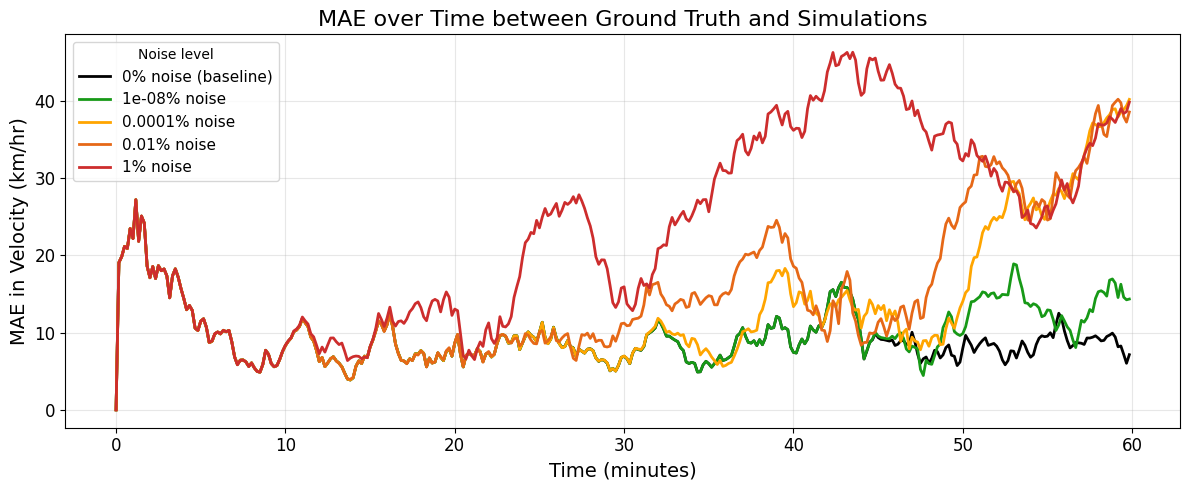

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


# Assumed to exist:
# v_gt: ground truth velocity, shape (time, segments)  e.g. v_gt = v_hat[:, 1:-1]
# v_sim: baseline simulation (0% noise), same shape as v_gt
# noisy_v_sim_dict: {percent_noise: v_noisy (time, segments)}
# percent_noise_list: list of noise levels used in the sims (e.g. [5, 10, 20])
# T: time step in hours

# --- MAE over time for baseline and noisy sims ---

num_time_steps = v_gt.shape[0]
time_minutes = np.arange(num_time_steps) * T * 60  # time axis in minutes

# Baseline (0% noise)
mae_baseline = np.mean(np.abs(v_gt - v_sim[0:-1, :]), axis=1)  # (time,)

# Noisy sims
mae_dict = {}
for percent_noise in percent_noise_list:
    v_noisy = noisy_v_sim_dict[percent_noise]
    mae_t = np.mean(np.abs(v_gt - v_noisy), axis=1)
    mae_dict[percent_noise] = mae_t

# --- Plot setup ---

fig, ax = plt.subplots(figsize=(12, 5))

# 1) Plot baseline in black (0% noise)
ax.plot(
    time_minutes,
    mae_baseline,
    label="0% noise (baseline)",
    color="k",
    linewidth=2,
)

# 2) Plot noisy curves with colors from green (low) → red (high) on a log noise scale

# Filter noise levels > 0 for LogNorm
noise_levels_nonzero = [p for p in percent_noise_list if p > 0]
vmin_p = min(noise_levels_nonzero)
vmax_p = max(noise_levels_nonzero)

# Log scaling for percent_noise → color
norm = colors.LogNorm(vmin=vmin_p, vmax=vmax_p)


# --- Custom green → red colormap without a light center ---

# Use darker shades so the middle isn't washed out
# You can tweak these hex codes if you want it punchier/subtler
green_dark = "#179917"  # dark green
red_dark   = "#CD2D2D"  # dark red
orange = "#FFA500"  # orange

cmap = LinearSegmentedColormap.from_list(
    "dark_green_red",
    [green_dark, orange, red_dark]
)


for percent_noise in sorted(noise_levels_nonzero):
    mae_t = mae_dict[percent_noise]
    color = cmap(norm(percent_noise))

    ax.plot(
        time_minutes,
        mae_t,
        label=f"{percent_noise}% noise",
        color=color,
        linewidth=2,
    )

# --- Labels, legend, colorbar, styling ---

ax.set_xlabel("Time (minutes)", fontsize=14)
ax.set_ylabel("MAE in Velocity (km/hr)", fontsize=14)
ax.set_title("MAE over Time between Ground Truth and Simulations", fontsize=16)
ax.grid(True, alpha=0.3)
ax.tick_params(axis="both", which="major", labelsize=12)
ax.legend(fontsize=11, title="Noise level")

plt.tight_layout()
plt.show()


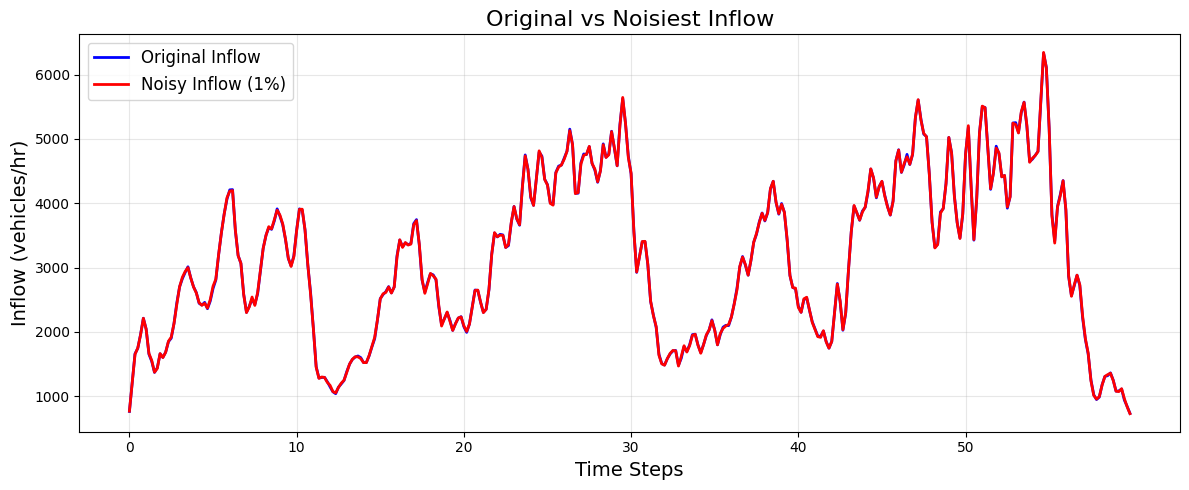

In [101]:
# Plot data_inflow next to noisiest data_inflow
plt.figure(figsize=(12, 5))
plt.plot(data_inflow, label="Original Inflow", color="blue", linewidth=2)
max_noise = max(percent_noise_list)
noisiest_inflow = noisy_inflow_dict[max_noise]
plt.plot(noisiest_inflow, label=f"Noisy Inflow ({max_noise}%)", color="red", linewidth=2)
plt.xlabel("Time Steps", fontsize=14)
plt.ylabel("Inflow (vehicles/hr)", fontsize=14)
plt.title("Original vs Noisiest Inflow", fontsize=16)

# Set x axis in minutes
num_time_steps = data_inflow.shape[0]
time_minutes = np.arange(num_time_steps) * T * 60  # time axis in minutes
plt.xticks(
    ticks=np.arange(0, num_time_steps, max(1, num_time_steps // 6)),
    labels=[f"{(i * T * 60):.0f}" for i in np.arange(0, num_time_steps, max(1, num_time_steps // 6))],
)   

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()